# Datset
We are using 2 datasets.<br>
1- Iris dataset<br>
2- Breast cancer detection Wisconsin (Unbalanced datset, 63% for class 0, 37% for class 1)

In [423]:
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.datasets import make_blobs
from skactiveml.pool import UncertaintySampling
from skactiveml.utils import MISSING_LABEL
from skactiveml.classifier import SklearnClassifier

In [424]:
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split

# Load the IRIS dataset.
iris = load_iris()
X_iris, y_true_iris = iris.data, iris.target

In [425]:
from sklearn.preprocessing import StandardScaler

def prepare_dataset(X, y):
    # Split the data into training (85%) and testing (15%) sets
    X, X_test, y_true, y_true_test = train_test_split(X, y, test_size=0.15, random_state=42)

    # Scale the data
    scaler = StandardScaler()
    X = scaler.fit_transform(X)
    X_test = scaler.transform(X_test)

    # Create an array with missing labels
    y = np.full(shape=y_true.shape, fill_value=MISSING_LABEL)

    # Use the first 10 samples as initial training data.
    y[:10] = y_true[:10]

    return X, y, y_true, X_test, y_true_test

X, y, y_true, X_test, y_true_test = prepare_dataset(X_iris, y_true_iris)

In [426]:
SAMPLES = [0, 0, 0]

In [427]:
def train_model(classifier, X, y, y_true, sampler, X_test, y_true_test, history=None, n_rounds=20):
    global SAMPLES
    
    # Initialize history if None
    if history is None:
        history = []
    
    classifier.fit(X, y)

    for i in range(n_rounds):
        # select sample based on sampler
        query_idx = sampler.query(X=X, y=y, clf=classifier)

        SAMPLES[y_true[query_idx][0]] += 1

        # simulate oracle
        y[query_idx] = y_true[query_idx]

        # train on new sample
        classifier.fit(X, y)
        
        # Record performance
        y_pred = classifier.predict(X_test)
        
        # Calculate accuracy
        accuracy = np.mean(y_pred == y_true_test)
        
        # Calculate cross-entropy loss
        y_proba = classifier.predict_proba(X_test)
        
        # One-hot encode true labels
        n_classes = len(np.unique(y_true_test))
        y_true_one_hot = np.zeros((len(y_true_test), n_classes))
        for j, label in enumerate(y_true_test):
            y_true_one_hot[j, label] = 1
        
        # Calculate cross-entropy loss
        eps = 1e-15
        y_proba = np.clip(y_proba, eps, 1 - eps)
        loss = -np.sum(y_true_one_hot * np.log(y_proba)) / len(y_true_test)
        
        # Add metrics to history
        history.append((loss, accuracy))

    return classifier, history

In [428]:
def end_to_end_bench(expriment_title, classifier, X, y_true, y, X_test, y_true_test, sampler, n_rounds=20):
    global SAMPLES
    SAMPLES = [0, 0, 0]

    # Train
    classifer, history = train_model(classifier, X, y, y_true, sampler, X_test, y_true_test, n_rounds=n_rounds)

    # Vsualize results
    import matplotlib.pyplot as plt
    # Extract loss and accuracy from history
    losses, accuracies = zip(*history)
    # Create subplots for loss and accuracy
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
    
    # Plot loss
    ax1.plot(losses)
    ax1.set_title(f'Cross-Entropy Loss | {expriment_title}')
    ax1.set_xlabel('Iteration')
    ax1.set_ylabel('Loss')

    # Plot accuracy
    ax2.plot(accuracies)
    ax2.set_title('Accuracy')
    ax2.set_xlabel('Iteration')
    ax2.set_ylabel('Accuracy')
    ax2.set_ylim(0, 1)

    # Adjust layout and display the plot
    plt.tight_layout()
    plt.show()

    return classifier, history

In [429]:
import numpy as np
from skactiveml.base import PoolQueryStrategy
from skactiveml.utils import check_scalar, check_type, check_X_y, MISSING_LABEL
from sklearn.utils import check_random_state

class RandomSampler(PoolQueryStrategy):
    def __init__(self, random_state=None):
        super().__init__(random_state=random_state)

    def query(self, X, y, clf=None, fit_clf=True, sample_weight=None,
              batch_size=1, return_utilities=False):
        
        # Find indices of unlabeled samples using the MISSING_LABEL constant
        unlabeled_indices = np.where(np.isnan(y))[0]
        # Randomly select indices from unlabeled samples
        query_indices = np.random.choice(unlabeled_indices, size=batch_size, replace=False)

        return query_indices

In [430]:
# Create classifier and query strategy.
sampler_least_confidence = UncertaintySampling(method='least_confident', random_state=42)
sampler_entropy = UncertaintySampling(method='entropy', random_state=42)
sampler_margin = UncertaintySampling(method='margin_sampling', random_state=42)
sampler_random = RandomSampler(random_state=42)

In [431]:
def generate_classifier(y_true):
    # Create a Logistic Regression classifier
    return SklearnClassifier(LogisticRegression(max_iter=1000), classes=np.unique(y_true))

def main(x_ground, y_ground, n_rounds):
    histories = []

    # Run end-to-end benchmark for different samplers
    X, y, y_true, X_test, y_true_test = prepare_dataset(x_ground, y_ground)
    _, history = end_to_end_bench("Random Sampler", generate_classifier(y_true), X, y_true, y, X_test, y_true_test, sampler_random, n_rounds=n_rounds)
    histories.append(history)
    print(f"Class 0 samples: {SAMPLES[0]}, Class 1 samples: {SAMPLES[1]}, Class 2 samples: {SAMPLES[2]}")

    X, y, y_true, X_test, y_true_test = prepare_dataset(x_ground, y_ground)
    _, history = end_to_end_bench("Least Confidence Sampling", generate_classifier(y_true), X, y_true, y, X_test, y_true_test, sampler_least_confidence, n_rounds=n_rounds)
    histories.append(history)
    print(f"Class 0 samples: {SAMPLES[0]}, Class 1 samples: {SAMPLES[1]}, Class 2 samples: {SAMPLES[2]}")

    X, y, y_true, X_test, y_true_test = prepare_dataset(x_ground, y_ground)
    _, history = end_to_end_bench("Entropy Sampling", generate_classifier(y_true), X, y_true, y, X_test, y_true_test, sampler_entropy, n_rounds=n_rounds)
    histories.append(history)
    print(f"Class 0 samples: {SAMPLES[0]}, Class 1 samples: {SAMPLES[1]}, Class 2 samples: {SAMPLES[2]}")

    X, y, y_true, X_test, y_true_test = prepare_dataset(x_ground, y_ground)
    _, history = end_to_end_bench("Margin Sampling", generate_classifier(y_true), X, y_true, y, X_test, y_true_test, sampler_margin, n_rounds=n_rounds)
    histories.append(history)
    print(f"Class 0 samples: {SAMPLES[0]}, Class 1 samples: {SAMPLES[1]}, Class 2 samples: {SAMPLES[2]}")

    return histories


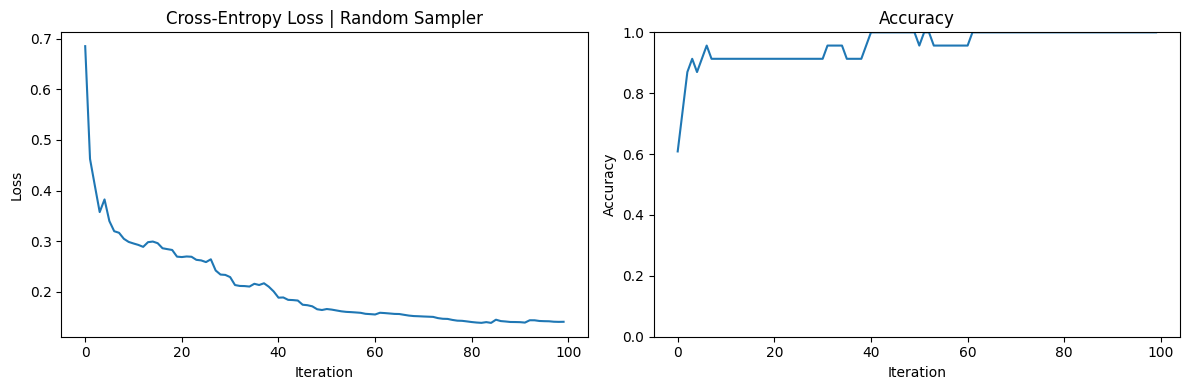

Class 0 samples: 31, Class 1 samples: 36, Class 2 samples: 33


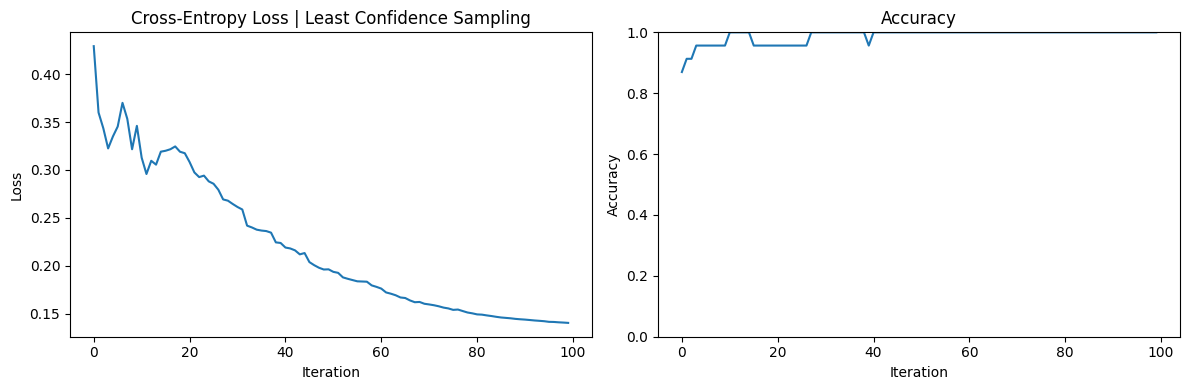

Class 0 samples: 27, Class 1 samples: 40, Class 2 samples: 33


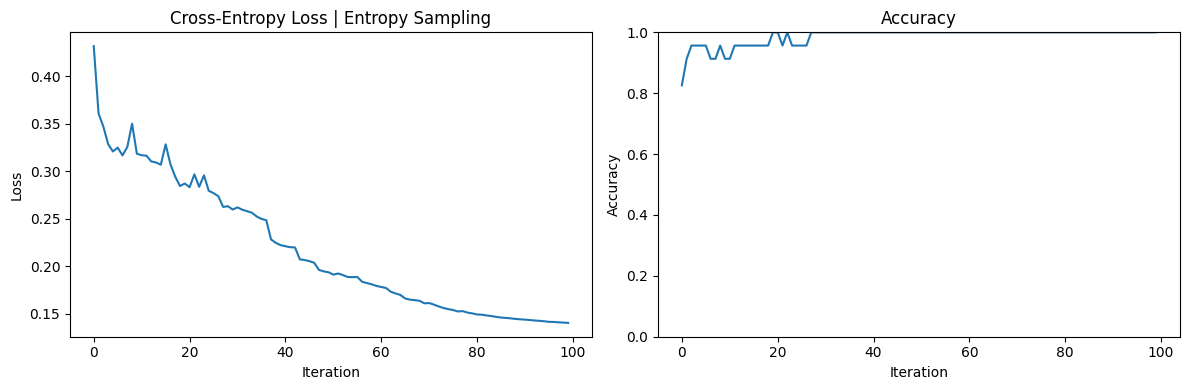

Class 0 samples: 27, Class 1 samples: 40, Class 2 samples: 33


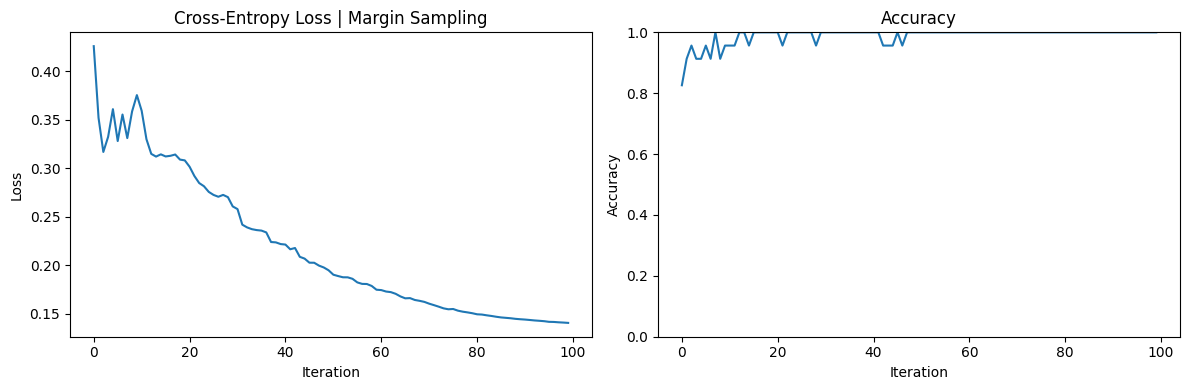

Class 0 samples: 27, Class 1 samples: 40, Class 2 samples: 33


In [432]:
histories = main(x_ground=X_iris, y_ground=y_true_iris, n_rounds=100)

In [433]:
import matplotlib.pyplot as plt

def plot_comparison(histories, names):
    """
    Plots multiple histories on separate plots for comparison.

    Parameters:
    - histories: List of histories, where each history is a list of (loss, accuracy) tuples.
    - names: List of names corresponding to each history for the legend.
    """
    # Plot accuracies
    plt.figure(figsize=(8, 4))
    for history, name in zip(histories, names):
        _, accuracies = zip(*history)
        plt.plot(accuracies, label=name)
    plt.title("Comparison of Samplers - Accuracy")
    plt.xlabel("Iteration")
    plt.ylabel("Accuracy")
    plt.ylim(0, 1)
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    # Plot losses
    plt.figure(figsize=(8, 4))
    for history, name in zip(histories, names):
        losses, _ = zip(*history)
        plt.plot(losses, label=name)
    plt.title("Comparison of Samplers - Loss")
    plt.xlabel("Iteration")
    plt.ylabel("Loss")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    plt.clf()
    plt.close('all')

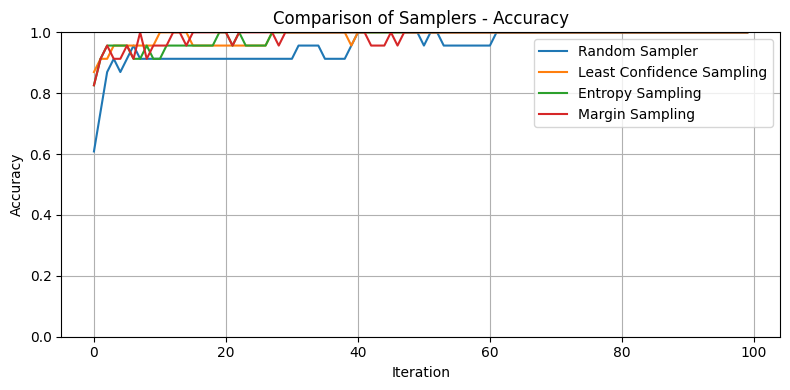

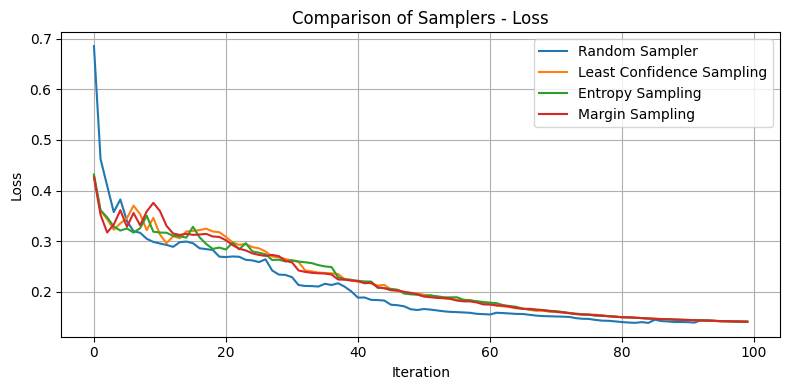

In [434]:
plot_comparison(histories, ["Random Sampler", "Least Confidence Sampling", "Entropy Sampling", "Margin Sampling"])

In [435]:
# Preparing the dataset for the breast cancer dataset

import pandas as pd
import numpy as np

# Load the dataset
df = pd.read_csv("data/data.csv")

# Discard the first column
df = df.iloc[:, 1:]

# Convert the diagnosis column to binary (0 for 'B' benign, 1 for 'M' malignant)
y = np.where(df.iloc[:, 0] == 'M', 1, 0)

# Drop last column and use the rest as features
X = df.iloc[:, 1:-1].values

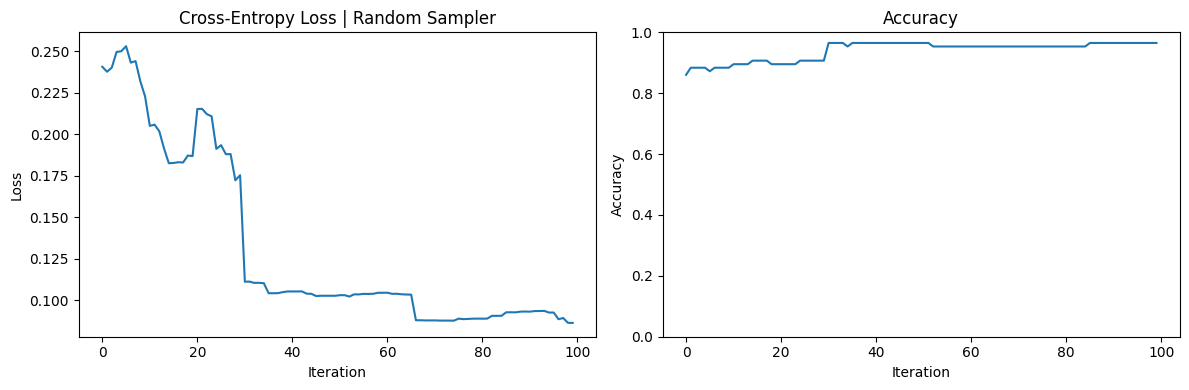

Class 0 samples: 64, Class 1 samples: 36, Class 2 samples: 0


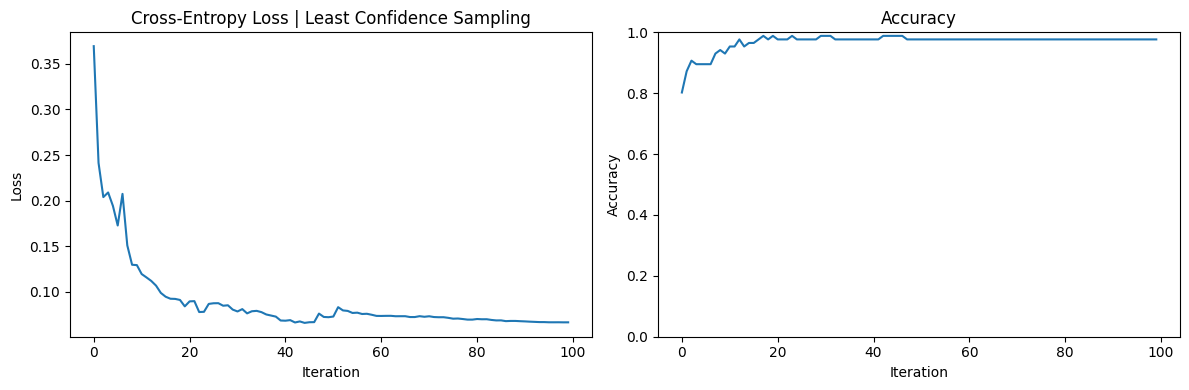

Class 0 samples: 57, Class 1 samples: 43, Class 2 samples: 0


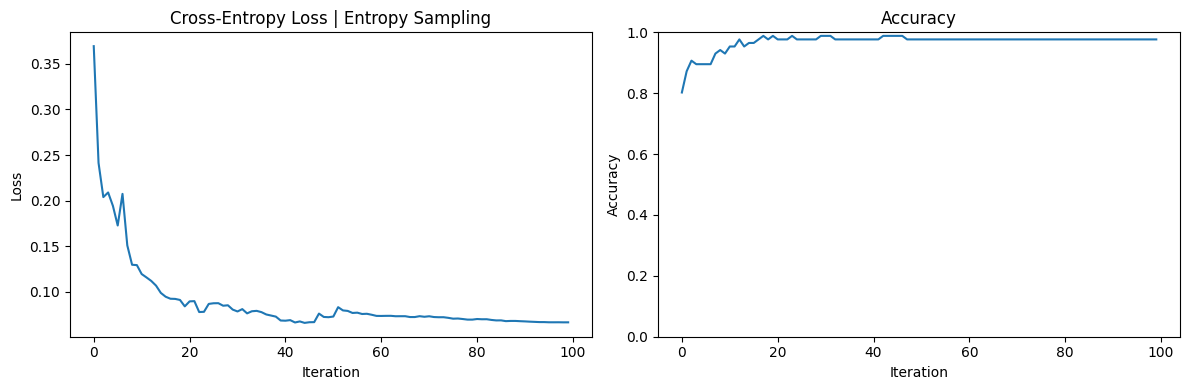

Class 0 samples: 57, Class 1 samples: 43, Class 2 samples: 0


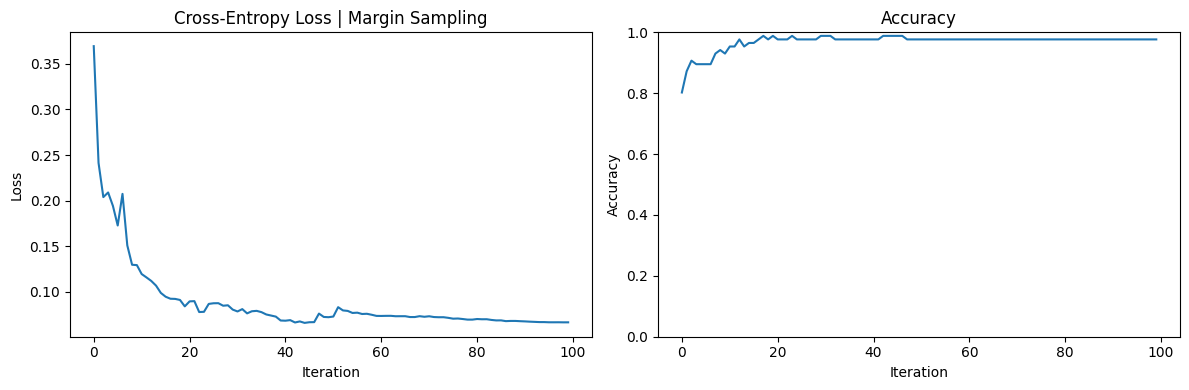

Class 0 samples: 57, Class 1 samples: 43, Class 2 samples: 0


In [436]:
histories = main(x_ground=X, y_ground=y, n_rounds=100)

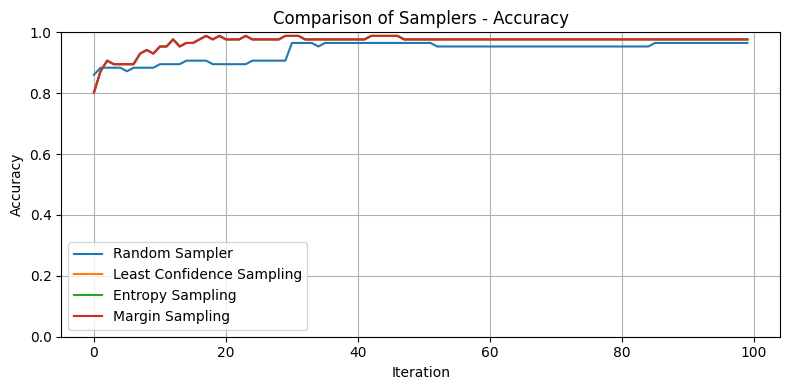

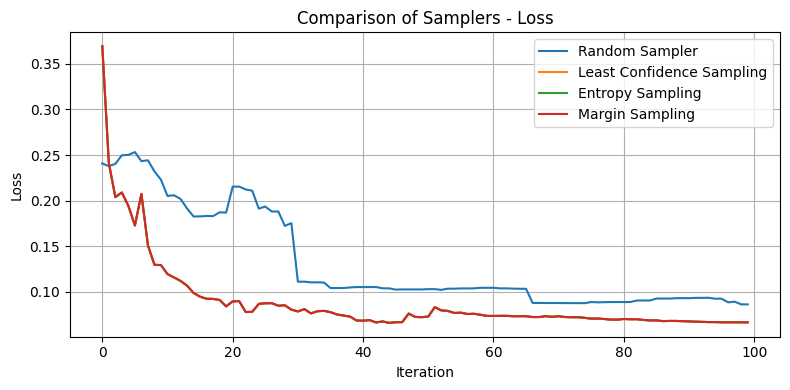

In [437]:
plot_comparison(histories, ["Random Sampler", "Least Confidence Sampling", "Entropy Sampling", "Margin Sampling"])